# Trabajo final - Jamil Alarcon




# Proyecto Final- Análisis de Ventas Online

El presente trabajo se basa en el análisis de un dataset de transacciones de una tienda online, el cual contiene información detallada sobre ventas realizadas en distintos países. La base de datos incluye datos como identificadores de facturas, productos, cantidades vendidas, precios unitarios, fechas de compra y clientes.

Esta información es de gran importancia para comprender el comportamiento de compra de los clientes, identificar los productos más demandados y analizar la distribución de las ventas a lo largo del tiempo y por región. A través del análisis de estos datos, es posible obtener insights relevantes que permitan mejorar la toma de decisiones comerciales y estratégicas.

## Objetivos



### Objetivo general
Analizar las ventas de una tienda online para identificar patrones y tendencias.



### Objetivos específicos
- Identificar los productos más vendidos  
- Analizar las ventas por país  
- Observar el comportamiento de las ventas en el tiempo  
- Identificar los clientes más importantes  

## Definición del problema

### Pregunta principal
¿Cómo se comportan las ventas en el tiempo y cuáles son los productos y países que generan más ingresos?



### Subpreguntas
- KPI1 ¿Qué productos son los más vendidos?
- KPI2 ¿Qué países generan más ventas?
- KPI3 ¿Cómo cambian las ventas por mes?
- KPI4 ¿Qué clientes compran más?

## Importar Librerias

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Busqueda y seleccion del dataset

In [16]:

drive_file_path = '/content/drive/MyDrive/Herramientas basicas para el analisis de datos/Online Retail.xlsx'
df = pd.read_excel(drive_file_path)

### Exploración inicial

In [17]:
# Mostrar las primeras 5 filas del DataFrame
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
# Revisar el número de filas y columnas
print("Número de filas y columnas:")
print(df.shape)

Número de filas y columnas:
(541909, 8)


In [19]:
# Identificar los tipos de datos y valores no nulos
print("Información del DataFrame (tipos de datos y valores no nulos):")
df.info()

Información del DataFrame (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [20]:
# Estadísticas descriptivas para columnas numéricas
print("Estadísticas descriptivas para columnas numéricas:")
display(df.describe())

Estadísticas descriptivas para columnas numéricas:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


##Limpieza de datos

### Manejo de Valores Nulos

In [21]:
# Contar la cantidad de valores nulos por columna
print("Valores nulos antes de la limpieza:")
print(df.isnull().sum())

Valores nulos antes de la limpieza:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [22]:
# Eliminar filas con valores nulos
df_cleaned = df.dropna()
print("\nValores nulos después de eliminar filas con nulos:")
print(df_cleaned.isnull().sum())


Valores nulos después de eliminar filas con nulos:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


### Eliminación de Duplicados

In [23]:
# Contar la cantidad de filas duplicadas
print("\nNúmero de filas duplicadas antes de la limpieza:", df_cleaned.duplicated().sum())

# Eliminar filas duplicadas
df_cleaned = df_cleaned.drop_duplicates()
print("Número de filas duplicadas después de eliminar duplicados:", df_cleaned.duplicated().sum())


Número de filas duplicadas antes de la limpieza: 5225
Número de filas duplicadas después de eliminar duplicados: 0


### Corrección de Tipos de Datos (Fechas)

In [24]:
# Convertir 'InvoiceDate' a tipo datetime (si aún no lo es)
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
print("\nTipo de dato de 'InvoiceDate' después de la conversión:", df_cleaned['InvoiceDate'].dtype)


Tipo de dato de 'InvoiceDate' después de la conversión: datetime64[ns]


### Creación de la columna de Ingreso Total (TotalPrice)

In [25]:
# Calcular TotalPrice
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
print("\nPrimeras filas con la nueva columna 'TotalPrice':")
display(df_cleaned.head())


Primeras filas con la nueva columna 'TotalPrice':


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Eliminación de Valores Incorrectos

In [26]:
# Eliminar transacciones con cantidades negativas (devoluciones)
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]

# Eliminar transacciones con precios unitarios negativos o cero
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]

print("\nNúmero de filas después de eliminar valores incorrectos:", df_cleaned.shape[0])


Número de filas después de eliminar valores incorrectos: 392692


## Análisis Exploratorio

### Análisis de Ventas en el Tiempo

In [27]:
# Extraer año, mes, día y hora de InvoiceDate
df_cleaned['Year'] = df_cleaned['InvoiceDate'].dt.year
df_cleaned['Month'] = df_cleaned['InvoiceDate'].dt.month_name()
df_cleaned['Day'] = df_cleaned['InvoiceDate'].dt.day_name()
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour

# Ventas totales por mes y año
sales_by_month = df_cleaned.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

# Ordenar meses correctamente para visualización
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
sales_by_month['Month'] = pd.Categorical(sales_by_month['Month'], categories=month_order, ordered=True)
sales_by_month = sales_by_month.sort_values(by=['Year', 'Month'])

print("Ventas totales por mes y año:")
display(sales_by_month)



Ventas totales por mes y año:


,Year,Month,TotalPrice
0,2010,December,570422.730
5,2011,January,568101.310
4,2011,February,446084.920
8,2011,March,594081.760
1,2011,April,468374.331
9,2011,May,677355.150
7,2011,June,660046.050
6,2011,July,598962.901
2,2011,August,644051.040
12,2011,September,950690.202


*Descripción EDA Ventas en el Tiempo:*

Este análisis nos permite observar la evolución de las ventas a lo largo del tiempo, identificando patrones de estacionalidad y tendencias anuales. La tabla muestra el total de ingresos generados por mes y año, lo cual es crucial para entender los ciclos de negocio.

### Análisis de Productos más Vendidos

In [28]:
# Productos más vendidos por cantidad
top_products_quantity = df_cleaned.groupby('Description')['Quantity'].sum().nlargest(10)
print("Top 10 productos más vendidos por cantidad:")
display(top_products_quantity)

# Productos más vendidos por ingreso total
top_products_revenue = df_cleaned.groupby('Description')['TotalPrice'].sum().nlargest(10)
print("\nTop 10 productos más vendidos por ingreso total:")
display(top_products_revenue)


Top 10 productos más vendidos por cantidad:


,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153



Top 10 productos más vendidos por ingreso total:


,TotalPrice
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


*Descripción EDA Productos más Vendidos:*

Aquí analizamos los productos desde dos perspectivas: la cantidad vendida (popularidad) y el ingreso total que generan (rentabilidad). Esto ayuda a identificar tanto los artículos de alta rotación como aquellos que, aunque quizás se vendan menos, aportan más valor económico.

### Análisis de Ventas por País

In [29]:
# Ventas totales por país
sales_by_country = df_cleaned.groupby('Country')['TotalPrice'].sum().nlargest(10)
print("Top 10 países por ingreso total:")
display(sales_by_country)


Top 10 países por ingreso total:


,TotalPrice
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


*Descripción EDA Ventas por País:*

Este análisis nos muestra la distribución geográfica de los ingresos. Al identificar los países que más contribuyen a las ventas, podemos enfocar estrategias de marketing y logística en los mercados más lucrativos.

###  Análisis de Clientes con más Compras

In [30]:
# Clientes con mayor ingreso total
top_customers = df_cleaned.groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
print("Top 10 clientes por ingreso total:")
display(top_customers)


Top 10 clientes por ingreso total:


,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


*Descripción EDA Clientes con más Compras:*

Aquí identificamos a los clientes más valiosos en términos de ingresos generados. Conocer a estos "clientes VIP" es fundamental para programas de fidelización y ofertas personalizadas.

## 8. Visualización

###  Ventas por Mes

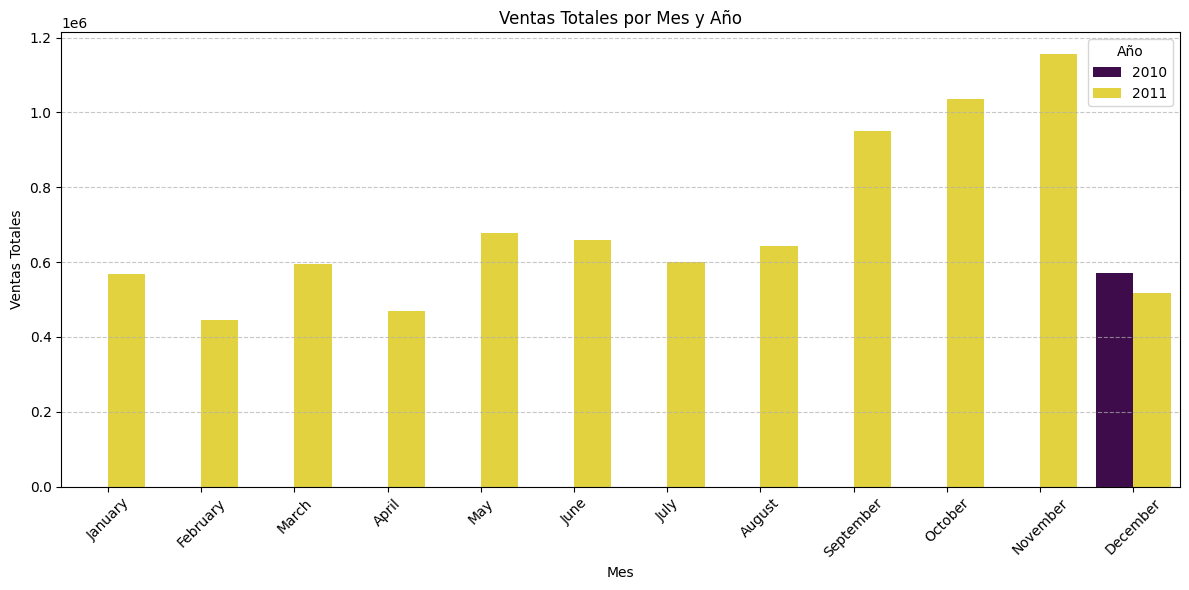

In [31]:


plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='TotalPrice', hue='Year', data=sales_by_month, palette='viridis')
plt.title('Ventas Totales por Mes y Año')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*Descripción del Gráfico Ventas por Mes:*

Este gráfico de barras muestra claramente la tendencia de ventas a lo largo de los meses, diferenciando por año. Es útil para visualizar la estacionalidad, como los picos de ventas hacia finales de año, y comparar el rendimiento entre diferentes años.

### Productos más Vendidos

/tmp/ipykernel_23371/4279988804.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_quantity.values, y=top_products_quantity.index, palette='magma')


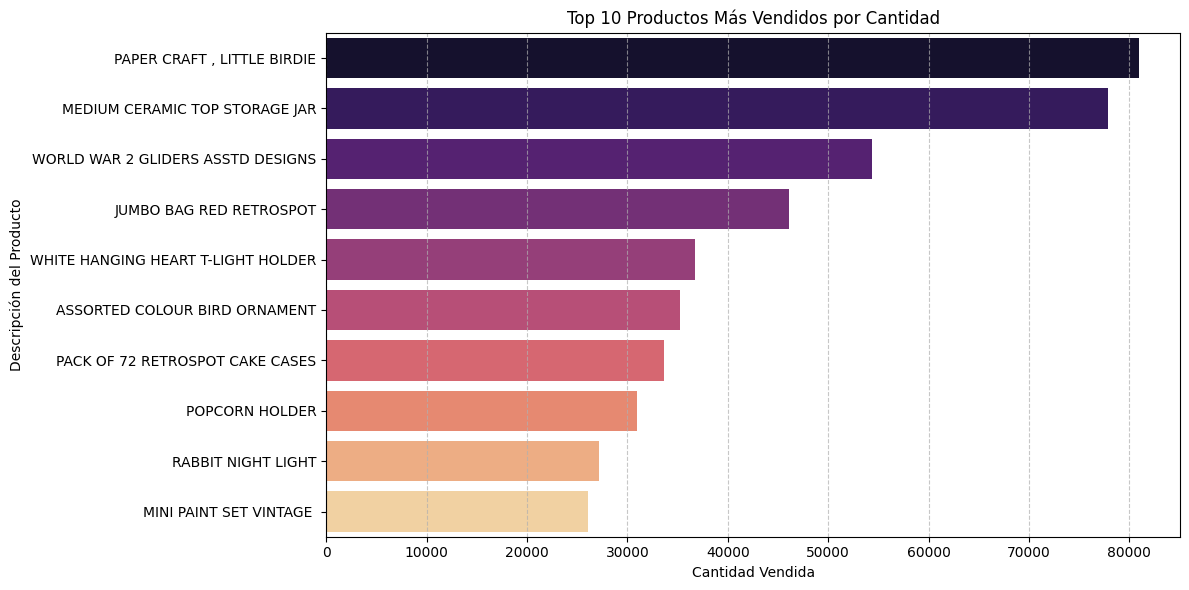

/tmp/ipykernel_23371/4279988804.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_revenue.values, y=top_products_revenue.index, palette='rocket')


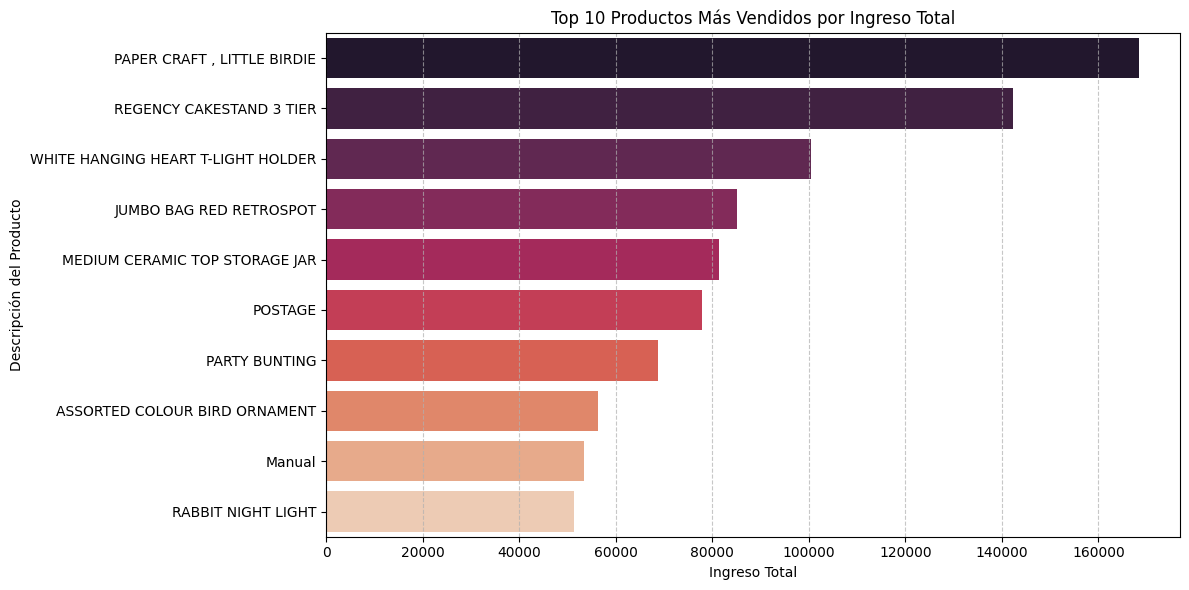

In [32]:


# Gráfico de los 10 productos más vendidos por cantidad
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_quantity.values, y=top_products_quantity.index, palette='magma')
plt.title('Top 10 Productos Más Vendidos por Cantidad')
plt.xlabel('Cantidad Vendida')
plt.ylabel('Descripción del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico de los 10 productos más vendidos por ingreso total
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_revenue.values, y=top_products_revenue.index, palette='rocket')
plt.title('Top 10 Productos Más Vendidos por Ingreso Total')
plt.xlabel('Ingreso Total')
plt.ylabel('Descripción del Producto')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*Descripción del Gráfico Productos más Vendidos:*

Estos dos gráficos de barras presentan los 10 productos principales, uno basado en la cantidad vendida y otro en el ingreso total. Comparar ambos permite identificar productos populares (alta cantidad) y productos de alto margen o precio (alto ingreso total).

### Ventas por País

/tmp/ipykernel_23371/2690657956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_country.values, y=sales_by_country.index, palette='cubehelix')


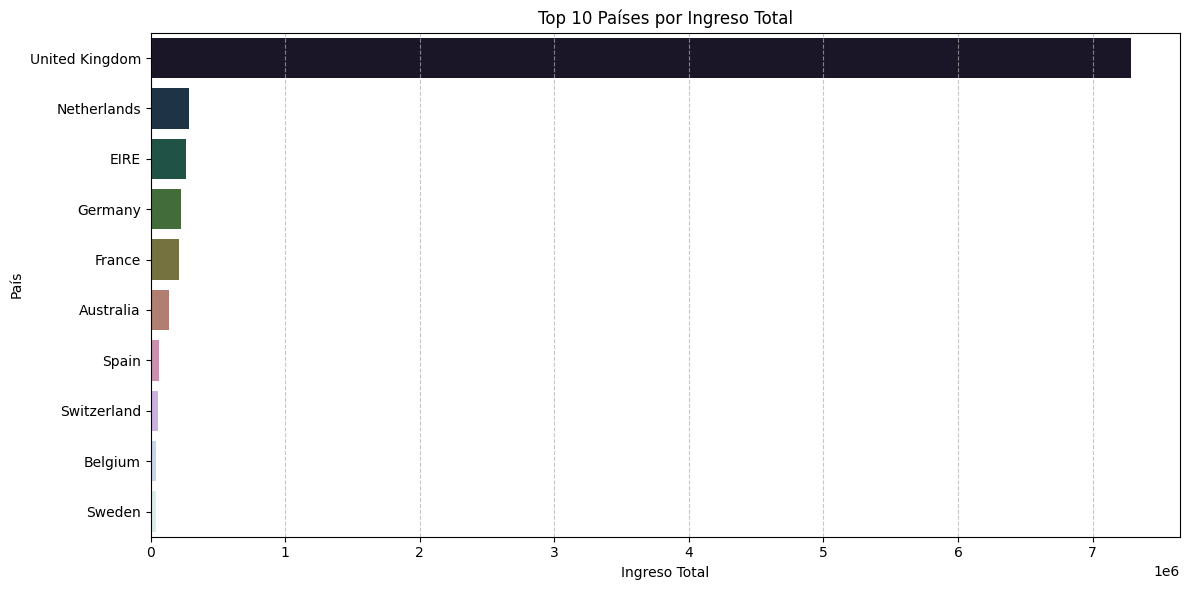

In [33]:


# Gráfico de los 10 países con mayor ingreso total
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_country.values, y=sales_by_country.index, palette='cubehelix')
plt.title('Top 10 Países por Ingreso Total')
plt.xlabel('Ingreso Total')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*Descripción del Gráfico Ventas por País:*

Este gráfico de barras visualiza los 10 países que más ingresos aportan. Es una herramienta poderosa para entender la concentración del mercado y la importancia de cada región geográfica para el negocio.

### Clientes Principales

/tmp/ipykernel_23371/3026827907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='flare')


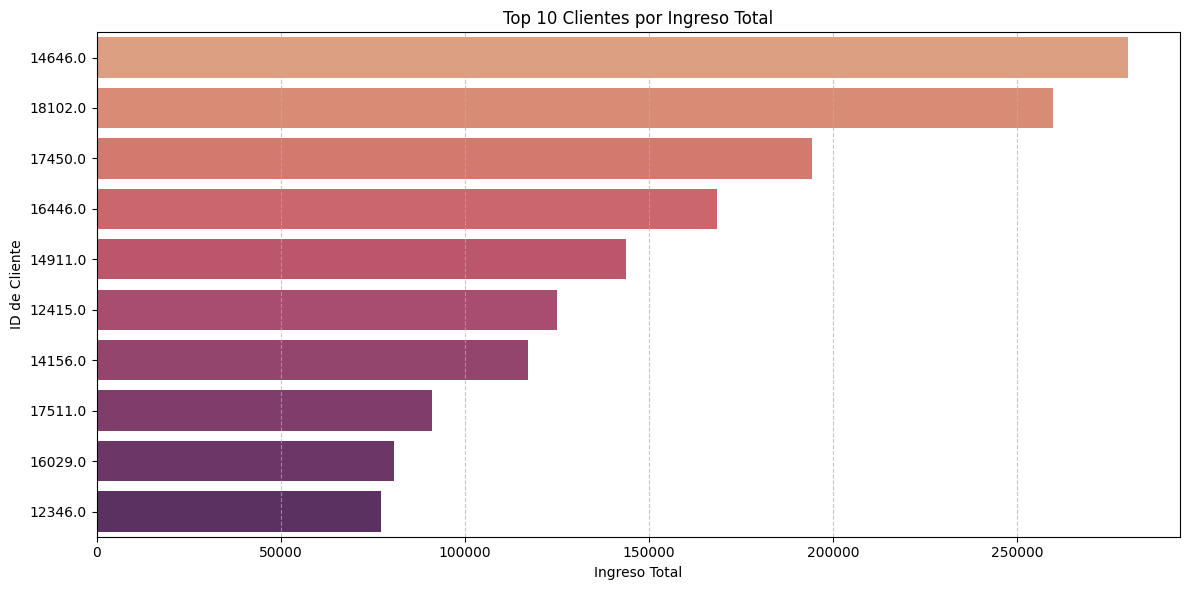

In [34]:


# Gráfico de los 10 clientes con mayor ingreso total
plt.figure(figsize=(12, 6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='flare')
plt.title('Top 10 Clientes por Ingreso Total')
plt.xlabel('Ingreso Total')
plt.ylabel('ID de Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


*Descripción del Gráfico Clientes Principales:*

Este gráfico de barras resalta a los 10 clientes que han generado la mayor cantidad de ingresos. Permite identificar rápidamente a los consumidores de alto valor, que pueden ser el objetivo de programas de fidelización especiales.

## 9. Hallazgos

A partir del análisis exploratorio y las visualizaciones, podemos destacar los siguientes hallazgos clave:

*   **Estacionalidad en Ventas:** Las ventas muestran una clara tendencia estacional, con un aumento significativo hacia el final del año, especialmente en los meses de octubre y noviembre. Esto sugiere un comportamiento de compra impulsado por temporadas festivas o promociones de fin de año.

*   **Dominio del Mercado Británico:** El Reino Unido es, con diferencia, el mercado más importante, generando una porción abrumadoramente mayor de los ingresos totales en comparación con otros países. Esto resalta la importancia estratégica de este mercado.

*   **Productos Estrella:** "PAPER CRAFT , LITTLE BIRDIE" es un producto consistentemente popular, destacando tanto en la cantidad vendida como en el ingreso total que genera. Otros productos como "REGENCY CAKESTAND 3 TIER" también son importantes por su alto valor en ingresos, aunque no se vendan en las mismas cantidades.

*   **Clientes de Alto Valor:** Se han identificado clientes específicos que realizan compras de gran volumen, como el `CustomerID` `14646.0`. Estos clientes representan una parte significativa de los ingresos y son fundamentales para la estrategia de retención y fidelización.


## 10. Exportar Resultados

In [35]:
# Ruta para guardar el archivo CSV en Google Drive
output_csv_path = '/content/drive/MyDrive/Herramientas basicas para el analisis de datos/online_retail_cleaned.csv'

# Exportar el DataFrame df_cleaned a CSV
df_cleaned.to_csv(output_csv_path, index=False)

print(f"DataFrame exportado exitosamente a: {output_csv_path}")

DataFrame exportado exitosamente a: /content/drive/MyDrive/Herramientas basicas para el analisis de datos/online_retail_cleaned.csv
